# Inside the prior: the synthetic data TFMs grow up on

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Innixma/kdd2026_tutorial_materials/blob/main/notebooks/03_inside_the_prior.ipynb)
[![GitHub Repo](https://img.shields.io/badge/GitHub-Repo-181717?logo=github)](https://github.com/Innixma/kdd2026_tutorial_materials)
[![Tutorial Website](https://img.shields.io/badge/Tutorial-Website-0a7aca?logo=googlechrome&logoColor=white)](https://kdd26-automl-hands-on.github.io/)

**Taming Structured Data Foundation Models with AutoML — KDD 2026 hands-on tutorial**

The tabular foundation models you have used so far never saw a single real dataset during
pretraining. TabICLv2, TabPFN, and TabFM are all trained on **millions of synthetic tables**
sampled from a *prior*: a random program that draws a causal graph, fills its nodes with
random functions, and executes it to produce features and a target.

This notebook runs that program. [nanotabicl](https://github.com/soda-inria/nanotabicl)
distills the TabICLv2 prior (see [the paper](https://arxiv.org/abs/2602.11139), §4.1) into a
single ~350-line file, `prior.py`: random Cauchy-sampled DAGs, a zoo of node functions
(linear maps, random MLPs, Gaussian-process features, random trees, discretizations),
30-odd activation functions, and a *learnability filter* that rejects datasets an
ExtraTrees model cannot beat chance on. We generate a gallery of datasets from it and look
at what the filter throws away.

> **Runtime**: well under a minute, CPU only — the prior is cheap; it is the transformer
> trained on it that needs the GPUs.

## Setup

We fetch `prior.py` straight from the nanotabicl repository — it has no dependencies beyond numpy, torch, and scikit-learn.

In [1]:
import urllib.request

urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/soda-inria/nanotabicl/main/prior.py", "prior.py"
)

import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

import prior

## A gallery of synthetic classification datasets

Each panel is one draw from the prior: two numeric features, a categorical target with 2-10
classes, 300 samples. `rand_dataset_filtered` keeps re-drawing until the learnability check
passes — an ExtraTrees model must beat the mean-prediction baseline out-of-bag with a
bootstrap p-value below 0.05 — so everything you see is *learnable structure*, not noise.

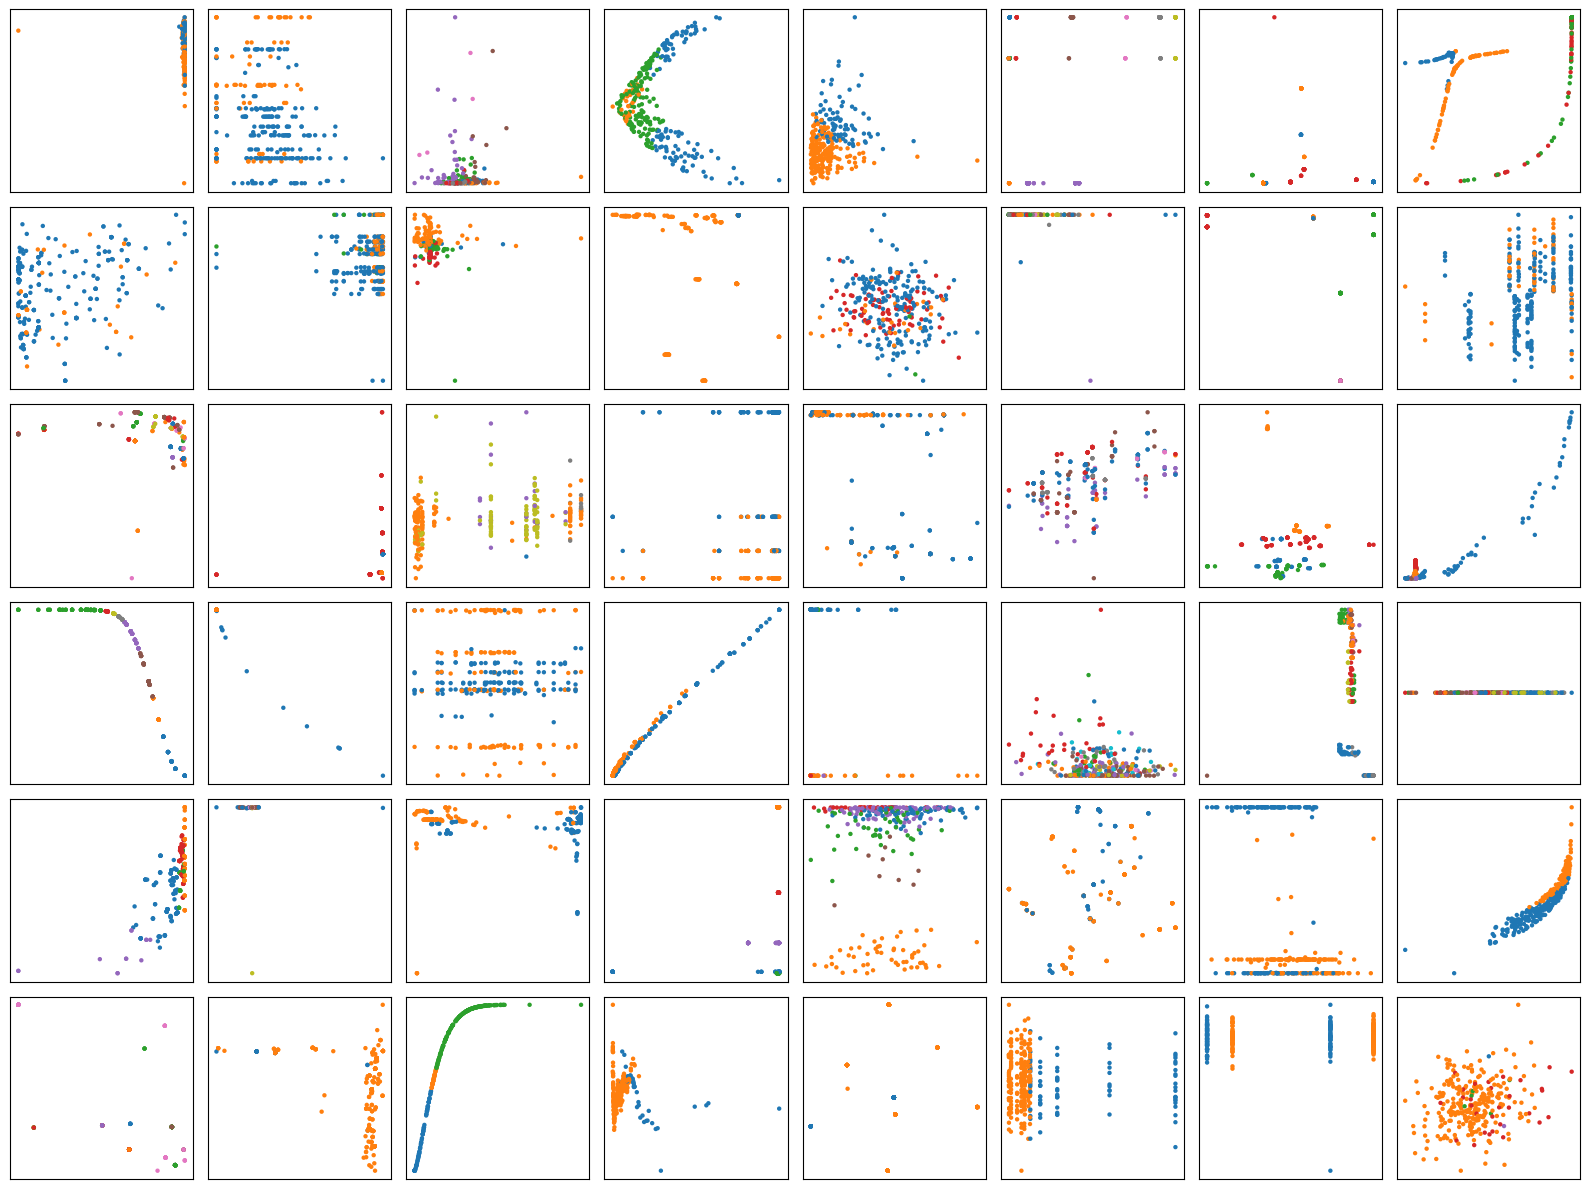

In [2]:
np.random.seed(1)
torch.manual_seed(1)

fig, axs = plt.subplots(6, 8, figsize=(16, 12))
for ax in axs.flat:
    n_classes = 2 if np.random.rand() < 0.5 else np.random.randint(3, 11)
    tensors = prior.rand_dataset_filtered(x_cat_sizes=[0] * 2, y_cat_sizes=[n_classes], n_samples=300)
    x = torch.cat([tensors["x_0"], tensors["x_1"]], dim=-1)
    y = tensors["y_0"].squeeze(-1)
    ax.set(xticks=[], yticks=[])
    ax.scatter(
        x[:, 0], x[:, 1], c=y,
        cmap=ListedColormap(plt.get_cmap("tab10").colors[:n_classes]),
        vmin=0, vmax=n_classes - 1, s=40, marker=".", linewidths=0,
    )
plt.tight_layout()
plt.show()

Look at the variety: axis-aligned splits that resemble tree partitions, smooth curved
boundaries, concentric and cluster structures, heavy class imbalance, label noise. A
transformer pretrained across millions of such draws has effectively *seen every kind of
decision boundary* before it meets your data — that is why a single forward pass with no
tuning was competitive in notebook 01.

## What the filter rejects

The prior's raw output is not all usable: many draws are pure noise, a constant target, or
a target decoupled from the features. Pretraining on those would teach the model nothing.
Here we run the same generator *without* the filter and split the draws by the same
learnability check, so you can see both sides of the cut.

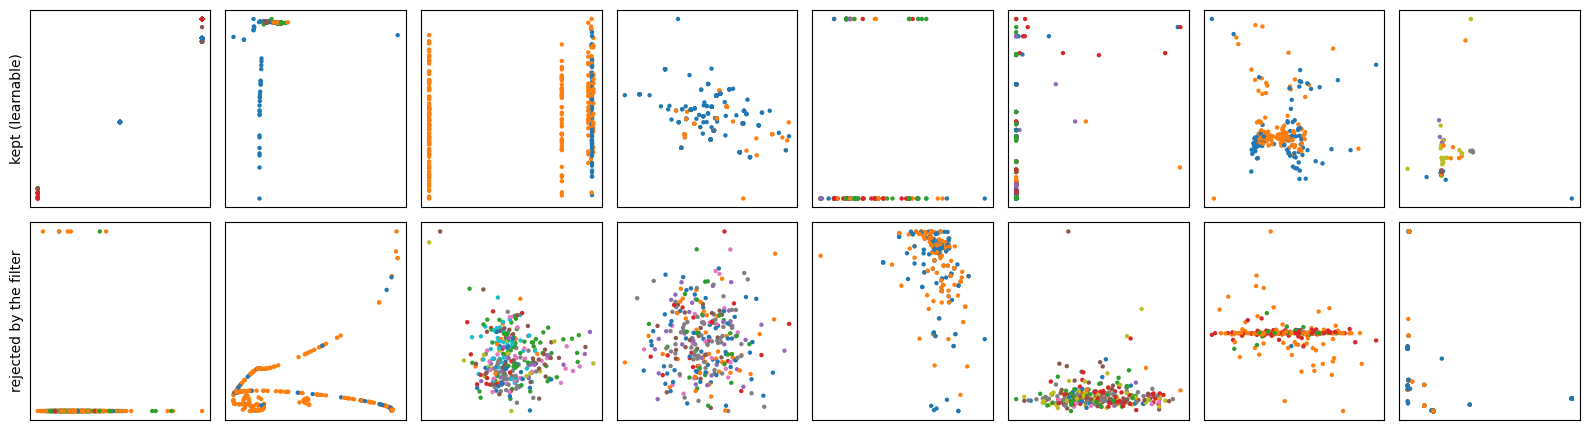

In [3]:
import torch.nn.functional as F
from sklearn.ensemble import ExtraTreesRegressor


def learnability_pval(tensors, n_classes):
    """The prior's filter statistic: bootstrap p-value that ExtraTrees beats the mean baseline."""
    X = torch.cat([t.float() for name, t in tensors.items() if name.startswith("x")], dim=-1).numpy()
    y = tensors["y_0"].long().squeeze(-1)
    Y = F.one_hot(y, num_classes=int(y.max().item() + 1)).float()
    Y = Y[:, :1] if Y.shape[1] == 2 else Y
    Y = Y.numpy()
    et = ExtraTreesRegressor(
        n_estimators=25, bootstrap=True, oob_score=True, n_jobs=1, random_state=1, max_depth=6
    ).fit(X, Y[:, 0] if Y.shape[1] == 1 else Y)
    Yhat = et.oob_prediction_[:, None] if et.oob_prediction_.ndim == 1 else et.oob_prediction_
    mask = ~np.isnan(Yhat).any(axis=1)
    imp = ((Y[mask] - Y.mean(axis=0, keepdims=True)) ** 2 - (Y[mask] - Yhat[mask]) ** 2).sum(axis=1)
    idx = np.random.default_rng(0).integers(0, len(imp), size=(200, len(imp)))
    return float(np.mean(imp[idx].mean(axis=1) <= 0.0))


np.random.seed(3)
torch.manual_seed(3)
kept, rejected = [], []
while len(kept) < 8 or len(rejected) < 8:
    n_classes = 2 if np.random.rand() < 0.5 else np.random.randint(3, 11)
    tensors = prior.rand_dataset_plain(x_cat_sizes=[0] * 2, y_cat_sizes=[n_classes], n_samples=300)
    bucket = kept if learnability_pval(tensors, n_classes) < 0.05 else rejected
    if len(bucket) < 8:
        bucket.append((tensors, n_classes))

fig, axs = plt.subplots(2, 8, figsize=(16, 4.4))
for row, (title, draws) in enumerate([("kept (learnable)", kept), ("rejected by the filter", rejected)]):
    for col, (tensors, n_classes) in enumerate(draws):
        ax = axs[row, col]
        x = torch.cat([tensors["x_0"], tensors["x_1"]], dim=-1)
        y = tensors["y_0"].squeeze(-1)
        ax.set(xticks=[], yticks=[])
        if col == 0:
            ax.set_ylabel(title, fontsize=10)
        ax.scatter(
            x[:, 0], x[:, 1], c=y,
            cmap=ListedColormap(plt.get_cmap("tab10").colors[:n_classes]),
            vmin=0, vmax=n_classes - 1, s=40, marker=".", linewidths=0,
        )
plt.tight_layout()
plt.show()

The rejected row is what noise from a random program looks like — labels sprayed across the
plane with no relation to the features. The filter is a quality gate on the curriculum: the
model spends its capacity on structure that generalizes, not on memorizing static.

## Why this matters for practice

- **The prior is the model's inductive bias.** Everything TabICLv2 "knows" — trees-like
  splits, smooth functions, cluster structure, categorical interactions — is in these draws.
  When your real dataset resembles the prior, in-context learning is extraordinarily
  effective; the corners where TFMs still lose (very wide sparse feature spaces, as in the
  TabArena `hiva_agnostic` case) are exactly the corners the prior underrepresents.
- **Scaling the prior scales the model.** Successive TFM generations (TabPFNv2, TabICLv2,
  TabFM) largely differ in richer priors, longer pretraining, and bigger contexts — not in
  per-dataset tricks.
- **It is all synthetic.** No real data is in the weights, which is why licensing
  conversations focus on the *weights'* terms, not on training-data provenance.

**Next**: [notebook 04](https://colab.research.google.com/github/Innixma/kdd2026_tutorial_materials/blob/main/notebooks/04_tfm_zoo.ipynb) puts the whole TFM zoo behind a single AutoGluon predictor.